# Upper-Air Temperature Sounding Versus HRRR F00

Compare an observed University of Wyoming upper-air temperature sounding from Siphon with the HRRR forecast-hour-zero temperature profile at the nearest HRRR grid point. The default case uses the same calendar date as `satelliteObservations.ipynb`, with a 12Z sounding cycle because routine upper-air soundings are typically available at 00Z and 12Z.

## Setup

This notebook downloads two independent datasets:

- Observed upper-air sounding: `WyomingUpperAir` from `siphon.simplewebservice.wyoming`.
- Forecast profile: HRRR pressure-level product through Herbie, using `fxx=0`.

If Siphon is not installed in the active environment, install it before running the notebook with `conda install -c conda-forge siphon` or `pip install siphon`.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import os

import numpy as np
import pandas as pd
import xarray as xr
from herbie import Herbie
from siphon.simplewebservice.wyoming import WyomingUpperAir

import matplotlib.pyplot as plt

repo_tmp = Path("tmp").resolve()
data_dir = Path("data").resolve()
(repo_tmp / "matplotlib").mkdir(parents=True, exist_ok=True)
(repo_tmp / "herbie-config").mkdir(parents=True, exist_ok=True)
(repo_tmp / "cache").mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))
os.environ.setdefault("HERBIE_CONFIG_PATH", str(repo_tmp / "herbie-config"))
os.environ.setdefault("XDG_CACHE_HOME", str(repo_tmp / "cache"))

'/home/dmmsp/Projects/observations-vs-forecasts/tmp/cache'

## Configuration

The date matches the existing satellite comparison notebook. Change `station_id`, `station_lat`, and `station_lon` together if you want to inspect a different upper-air site.

In [2]:
# Same calendar date as satelliteObservations.ipynb.
sounding_time_utc = datetime(2026, 6, 2, 12, 0, tzinfo=timezone.utc)

# HRRR forecast hour zero for the same cycle as the observed sounding.
hrrr_run_time_utc = sounding_time_utc
hrrr_forecast_hour = 0

# Default station: Buffalo, NY upper-air site.
station_id = "BUF"
station_name = "Buffalo, NY"
station_lat = 42.94
station_lon = -78.74

pressure_ticks_hpa = [1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]
plot_top_hpa = 100

## Observed Sounding

Pull the temperature profile from the University of Wyoming archive via Siphon and keep the pressure and temperature columns needed for the comparison.

In [3]:
def fetch_observed_temperature_sounding(valid_time, station):
    """Return observed pressure and temperature from WyomingUpperAir."""
    sounding = WyomingUpperAir.request_data(valid_time, station)
    required = ["pressure", "temperature"]
    missing = [column for column in required if column not in sounding.columns]
    if missing:
        raise KeyError(f"WyomingUpperAir result is missing columns: {missing}")

    profile = (
        sounding[required]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .rename(columns={"pressure": "pressure_hpa", "temperature": "observed_temperature_c"})
        .sort_values("pressure_hpa", ascending=False)
        .reset_index(drop=True)
    )

    if profile.empty:
        raise ValueError(f"No usable temperature sounding data for {station} at {valid_time:%Y-%m-%d %H UTC}")

    return profile, sounding


observed_profile, raw_sounding = fetch_observed_temperature_sounding(sounding_time_utc, station_id)
print(f"Observed levels: {len(observed_profile)}")
observed_profile.head(10)

Observed levels: 190


,pressure_hpa,observed_temperature_c
0,999.0,9.8
1,995.0,9.2
2,993.0,10.0
3,992.0,12.0
4,989.0,13.2
5,977.0,15.0
6,953.5,13.7
7,925.0,12.0
8,919.8,11.5
9,911.0,10.6


## HRRR F00 Profile

Download HRRR pressure-level temperature fields for forecast hour zero, then extract the nearest grid point to the sounding station.

In [4]:
def pressure_coord_name(data_array):
    """Find the pressure coordinate cfgrib uses for isobaric HRRR levels."""
    for name in data_array.coords:
        lowered = name.lower()
        if "isobaric" in lowered or lowered in {"pressure", "level"}:
            return name
    raise KeyError(f"Could not find an isobaric pressure coordinate in {list(data_array.coords)}")


def nearest_grid_indices(latitude, longitude, target_lat, target_lon):
    """Return y/x indices for the nearest lat/lon grid point."""
    lon = ((longitude + 180.0) % 360.0) - 180.0
    lon_scale = np.cos(np.deg2rad(target_lat))
    distance2 = (latitude - target_lat) ** 2 + ((lon - target_lon) * lon_scale) ** 2
    flat_index = int(np.nanargmin(distance2.values))
    return np.unravel_index(flat_index, distance2.shape)


def fetch_hrrr_temperature_profile(run_time, fxx, target_lat, target_lon):
    """Return HRRR pressure-level temperature at the nearest grid point."""
    run_time_naive = pd.Timestamp(run_time).tz_convert("UTC").tz_localize(None).to_pydatetime()
    hrrr = Herbie(run_time_naive, model="hrrr", product="prs", fxx=fxx, save_dir=data_dir)

    # Pressure-level temperature records only.
    subset_path = hrrr.download(":TMP:[0-9]+ mb:", verbose=False)
    if isinstance(subset_path, (list, tuple)):
        subset_path = subset_path[0]

    ds = xr.open_dataset(
        subset_path,
        engine="cfgrib",
        backend_kwargs={"indexpath": ""},
    )
    if "t" not in ds:
        raise KeyError(f"Expected HRRR variable 't', found {list(ds.data_vars)}")

    lat = ds["latitude"]
    lon = ds["longitude"]
    y_index, x_index = nearest_grid_indices(lat, lon, target_lat, target_lon)
    y_dim, x_dim = lat.dims

    temperature_k = ds["t"].isel({y_dim: y_index, x_dim: x_index}).squeeze().load()
    pressure_name = pressure_coord_name(temperature_k)
    pressure = temperature_k[pressure_name].values.astype(float)

    profile = (
        pd.DataFrame(
            {
                "pressure_hpa": pressure,
                "hrrr_temperature_c": temperature_k.values.astype(float) - 273.15,
            }
        )
        .dropna()
        .sort_values("pressure_hpa", ascending=False)
        .reset_index(drop=True)
    )

    nearest_lat = float(lat.isel({y_dim: y_index, x_dim: x_index}).values)
    nearest_lon = float((((lon.isel({y_dim: y_index, x_dim: x_index}) + 180.0) % 360.0) - 180.0).values)
    ds.close()

    return profile, {
        "grib_subset_path": str(subset_path),
        "grid_y": int(y_index),
        "grid_x": int(x_index),
        "grid_lat": nearest_lat,
        "grid_lon": nearest_lon,
    }


hrrr_profile, hrrr_metadata = fetch_hrrr_temperature_profile(
    hrrr_run_time_utc,
    hrrr_forecast_hour,
    station_lat,
    station_lon,
)
print(hrrr_metadata)
hrrr_profile.head(10)

✅ Found ┊ model=hrrr ┊ product=prs ┊ 2026-Jun-02 12:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


{'grib_subset_path': '/home/dmmsp/Projects/observations-vs-forecasts/data/hrrr/20260602/subset_09efb54e__hrrr.t12z.wrfprsf00.grib2', 'grid_y': 746, 'grid_x': 1406, 'grid_lat': 42.949262544493465, 'grid_lon': -78.74728507411908}


,pressure_hpa,hrrr_temperature_c
0,1000.0,12.398370
1,975.0,13.856958
2,950.0,13.436670
3,925.0,11.827020
4,900.0,10.159784
5,875.0,8.425226
6,850.0,6.546167
7,825.0,4.682581
8,800.0,2.745599
9,775.0,0.732568


## Compare On Observed Levels

Interpolate the HRRR temperature profile to observed pressure levels so the temperature bias is computed at matching vertical coordinates.

In [5]:
def interpolate_model_to_observed_levels(observed, model):
    """Interpolate model temperature to observed pressure levels."""
    model_sorted = model.sort_values("pressure_hpa", ascending=True)
    observed_in_range = observed[
        observed["pressure_hpa"].between(
            model_sorted["pressure_hpa"].min(),
            model_sorted["pressure_hpa"].max(),
        )
    ].copy()

    observed_in_range["hrrr_temperature_c"] = np.interp(
        observed_in_range["pressure_hpa"].values,
        model_sorted["pressure_hpa"].values,
        model_sorted["hrrr_temperature_c"].values,
    )
    observed_in_range["hrrr_minus_observed_c"] = (
        observed_in_range["hrrr_temperature_c"]
        - observed_in_range["observed_temperature_c"]
    )
    return observed_in_range


comparison = interpolate_model_to_observed_levels(observed_profile, hrrr_profile)
metrics = {
    "station": station_id,
    "valid_time_utc": sounding_time_utc.strftime("%Y-%m-%d %H:%M UTC"),
    "matched_levels": int(len(comparison)),
    "mean_bias_c": float(comparison["hrrr_minus_observed_c"].mean()),
    "mean_absolute_error_c": float(comparison["hrrr_minus_observed_c"].abs().mean()),
    "max_absolute_error_c": float(comparison["hrrr_minus_observed_c"].abs().max()),
}
metrics

{'station': 'BUF',
 'valid_time_utc': '2026-06-02 12:00 UTC',
 'matched_levels': 147,
 'mean_bias_c': 0.12936328291084312,
 'mean_absolute_error_c': 0.4935685628255225,
 'max_absolute_error_c': 3.4900878906250234}

## Temperature Profile Plot

The left panel compares the observed and HRRR forecast-hour-zero temperature profiles. The right panel shows HRRR minus observed temperature after interpolation to observed pressure levels.

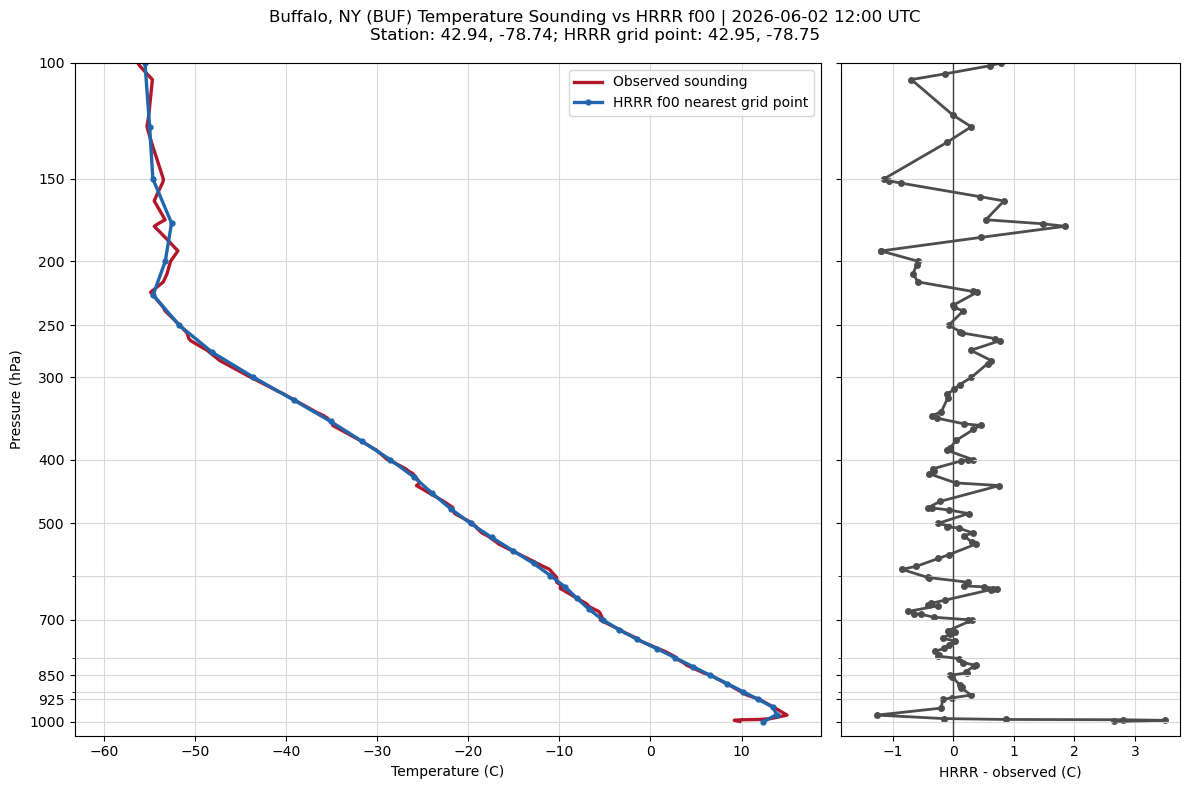

,station,valid_time_utc,matched_levels,mean_bias_c,mean_absolute_error_c,max_absolute_error_c
0,BUF,2026-06-02 12:00 UTC,147,0.129363,0.493569,3.490088


In [6]:
valid_label = sounding_time_utc.strftime("%Y-%m-%d %H:%M UTC")
grid_label = f"{hrrr_metadata['grid_lat']:.2f}, {hrrr_metadata['grid_lon']:.2f}"

fig, (ax_profile, ax_bias) = plt.subplots(
    ncols=2,
    figsize=(12, 8),
    sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1.0]},
)

ax_profile.plot(
    observed_profile["observed_temperature_c"],
    observed_profile["pressure_hpa"],
    color="#b2182b",
    linewidth=2.4,
    label="Observed sounding",
)
ax_profile.plot(
    hrrr_profile["hrrr_temperature_c"],
    hrrr_profile["pressure_hpa"],
    color="#2166ac",
    linewidth=2.4,
    marker="o",
    markersize=3.5,
    label="HRRR f00 nearest grid point",
)
ax_profile.set_xlabel("Temperature (C)")
ax_profile.set_ylabel("Pressure (hPa)")
ax_profile.grid(True, which="both", color="0.85", linewidth=0.8)
ax_profile.legend(loc="best")

ax_bias.axvline(0, color="0.25", linewidth=1.0)
ax_bias.plot(
    comparison["hrrr_minus_observed_c"],
    comparison["pressure_hpa"],
    color="#4d4d4d",
    linewidth=2.0,
)
ax_bias.scatter(
    comparison["hrrr_minus_observed_c"],
    comparison["pressure_hpa"],
    color="#4d4d4d",
    s=16,
)
ax_bias.set_xlabel("HRRR - observed (C)")
ax_bias.grid(True, which="both", color="0.85", linewidth=0.8)

for ax in (ax_profile, ax_bias):
    ax.set_yscale("log")
    ax.set_ylim(max(1050, observed_profile["pressure_hpa"].max() + 25), plot_top_hpa)
    ax.set_yticks(pressure_ticks_hpa)
    ax.set_yticklabels([str(tick) for tick in pressure_ticks_hpa])

fig.suptitle(
    f"{station_name} ({station_id}) Temperature Sounding vs HRRR f00 | {valid_label}\n"
    f"Station: {station_lat:.2f}, {station_lon:.2f}; HRRR grid point: {grid_label}",
    y=0.98,
)
fig.tight_layout()
plt.show()

pd.DataFrame([metrics])

## Notes

- The observed sounding and HRRR f00 profile are matched by cycle time, not by launch drift.
- The HRRR profile is sampled at the nearest grid point to the configured station latitude and longitude.
- Change the station configuration cell to compare a different sounding site on the same date.